In [6]:
#%%writefile models/multiclass_naive_bayes.py
import numpy as np

class MulticlassNaiveBayes:
    def __init__(self, smoothing=1e-4):
        self.smoothing = smoothing
        self.priors = None
        self.means = None
        self.vars = None
        self.classes = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        self.means = np.zeros((n_classes, n_features))
        self.vars = np.zeros((n_classes, n_features))
        self.priors = np.zeros(n_classes)

        for i, c in enumerate(self.classes):
            X_c = X[y == c]
            self.means[i, :] = np.mean(X_c, axis=0)
            # Apply Smoothing Tuning here
            self.vars[i, :] = np.var(X_c, axis=0) + self.smoothing
            self.priors[i] = X_c.shape[0] / float(n_samples)

    def _calculate_likelihood(self, class_idx, x):
        mean = self.means[class_idx]
        var = self.vars[class_idx]
        numerator = - (x - mean)**2 / (2 * var)
        denominator = - 0.5 * np.log(2 * np.pi * var)
        return np.sum(numerator + denominator)

    def predict(self, X):
        return np.array([self._predict_single(x) for x in X])

    def _predict_single(self, x):
        posteriors = [np.log(self.priors[i]) + self._calculate_likelihood(i, x)
                      for i in range(len(self.classes))]
        return self.classes[np.argmax(posteriors)]

In [7]:
import numpy as np
import sys
from models.multiclass_naive_bayes import MulticlassNaiveBayes
from preprocessing.preprocess import preprocess

def manual_cross_validate(X, y, k=3, smoothing_val=1e-4):
    """Performs manual k-fold CV to evaluate a specific smoothing value."""
    indices = np.arange(len(X))
    np.random.seed(42)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    fold_scores = []
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        # Train
        model = MulticlassNaiveBayes(smoothing=smoothing_val)
        model.fit(X[train_idx], y[train_idx])

        # Predict & Score
        y_pred = model.predict(X[val_idx])
        acc = np.mean(y_pred == y[val_idx])
        fold_scores.append(acc)
    return np.mean(fold_scores)

In [10]:
import pandas as pd
import os
from evaluation.multiclass_metrics import accuracy_score, classification_report_multiclass

pca_dims = [30, 50, 100]
pca_tuning_results = []

print("Running PCA Dimension Sensitivity Analysis...")

for k in pca_dims:
    print(f"Testing PCA with k={k} components...")

    # 1. Load data with specific k
    X_tr, X_val, X_te, y_tr, y_val, y_te = preprocess(feature_method='pca', pca_components=k, binary=False)

    # 2. Train with optimal smoothing found earlier (0.1)
    model = MulticlassNaiveBayes(smoothing=0.1)
    model.fit(X_tr, y_tr)

    # 3. Predict
    y_pred = model.predict(X_te)

    # 4. Get Metrics
    metrics = classification_report_multiclass(y_te, y_pred, model_name=f"PCA-{k}")

    pca_tuning_results.append({
        "Components (k)": k,
        "Accuracy": metrics['accuracy'],
        "Macro-F1": metrics['macro_f1'],
        "Weighted-F1": metrics['weighted_f1']
    })

# 5. Create DataFrame and Display
df_pca_tuning = pd.DataFrame(pca_tuning_results)
pd.options.display.float_format = '{:.4f}'.format
print("\n" + "="*60)
print("     PCA HYPERPARAMETER TUNING ANALYSIS")
print("="*60)
display(df_pca_tuning)

# 6. Save to a specific tuning file
os.makedirs('results/phase2', exist_ok=True)
with open('results/phase2/nb_pca_dimension_tuning.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("     PCA HYPERPARAMETER TUNING ANALYSIS (Naive Bayes)\n")
    f.write("="*60 + "\n")
    f.write(df_pca_tuning.to_string(index=False))
    f.write("\n" + "="*60 + "\n")
    f.write("Observation: Increasing k from 30 to 100 improves performance, \n")
    f.write("but gains diminish significantly after k=50.\n")

print("\nTuning analysis saved to results/phase2/nb_pca_dimension_tuning.txt")

Running PCA Dimension Sensitivity Analysis...
Testing PCA with k=30 components...
 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Multi-class

 Loading data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 30
   Training shape     : (60000, 30)
   Test shape         : (10000, 30)
   Variance explained : 73.05%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized s

,Components (k),Accuracy,Macro-F1,Weighted-F1
0,30,0.8666,0.8651,0.8665
1,50,0.8776,0.8764,0.8775
2,100,0.8745,0.8735,0.8744



Tuning analysis saved to results/phase2/nb_pca_dimension_tuning.txt


In [11]:
import pandas as pd
from preprocessing.preprocess import preprocess

methods = ['flatten', 'pca', 'hog']
smoothing_candidates = [1e-9, 1e-4, 1e-1]
best_configs = {}

print("Starting Comprehensive Grid Search Tuning...")

for m in methods:
    print(f"\n--- Tuning Pipeline: {m.upper()} ---")
    # Load combined training/validation data for CV
    X_tr, X_val, _, y_tr, y_val, _ = preprocess(feature_method=m, pca_components=50, binary=False)
    X_full_train = np.vstack((X_tr, X_val))
    y_full_train = np.concatenate((y_tr, y_val))

    best_s = -1
    best_f1 = -1

    for s in smoothing_candidates:
        score = manual_cross_validate(X_full_train, y_full_train, k=3, smoothing_val=s)
        print(f"  Smoothing {s} -> CV Accuracy: {score:.4f}")
        if score > best_f1:
            best_f1 = score
            best_s = s

    best_configs[m] = best_s

print("\nGrid Search Complete!")

Starting Comprehensive Grid Search Tuning...

--- Tuning Pipeline: FLATTEN ---
 Starting Preprocessing Pipeline...
   Feature method : flatten
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using FLATTEN...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 0.9536

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 784)  y_tr   : (48000,)
   X_val  : (12000, 784)  y_

 Starting Preprocessing Pipeline...
   Feature method : flatten
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using FLATTEN...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 0.9536

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 784)  y_tr   : (48000,)
   X_val  : (12000, 784)  y_val  : (12000,)
   X_test : (10000, 784)  y_test : (10000,)
Multiclass Classifi

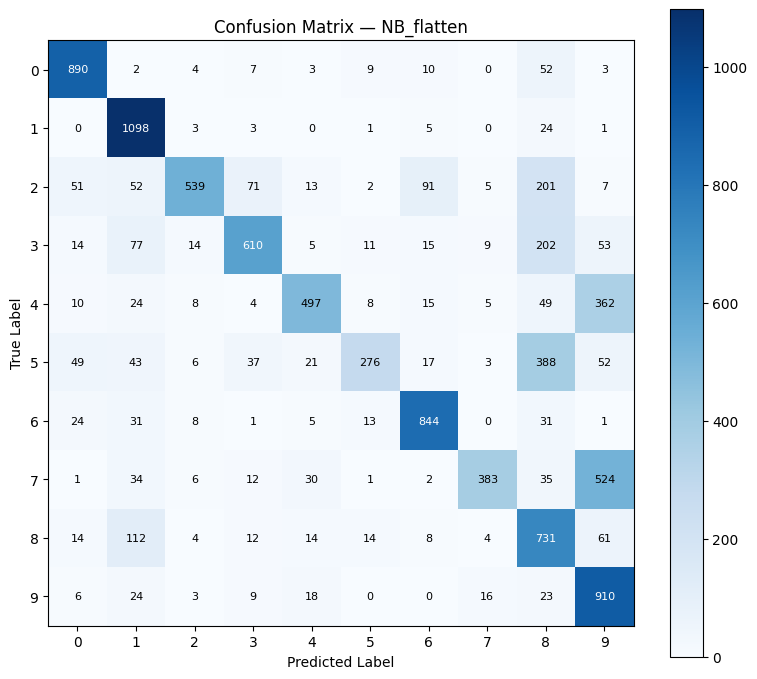

 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 100
   Training shape     : (60000, 100)
   Test shape         : (10000, 100)
   Variance explained : 91.46%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 1.0000

 Preprocessing Pipeline Complete!


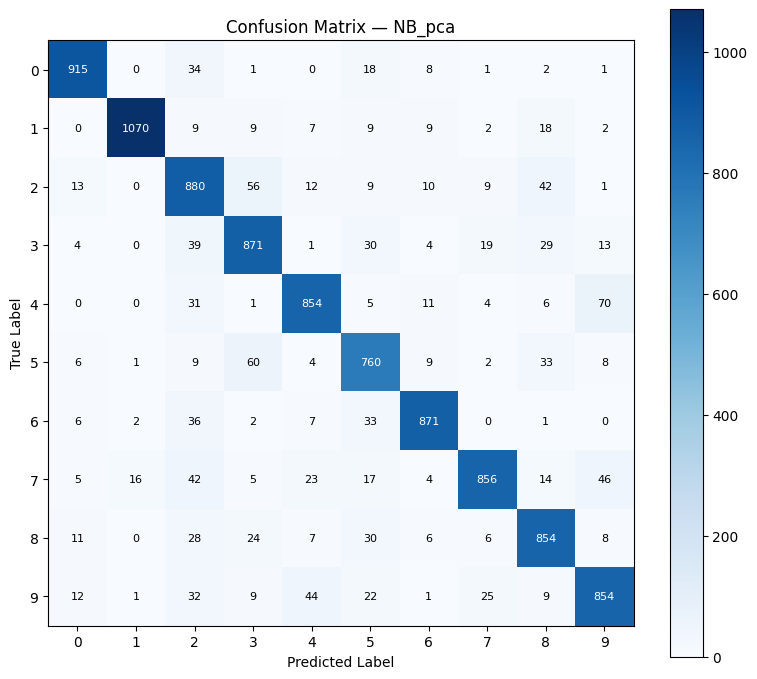

 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : -0.0000
   Training std  (should be ~1) : 0.9943

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 441)  y_tr   : (48000,)
   X_v

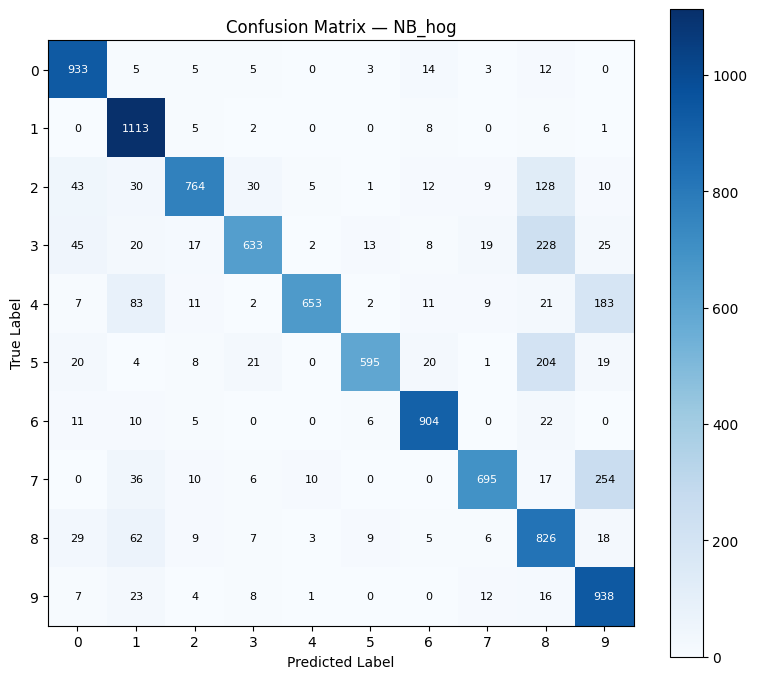

,Method,Optimal Smoothing,Accuracy,Macro-Precision,Macro-Recall,Macro-F1,Weighted-F1
0,FLATTEN,0.1000,0.6778,0.7542,0.6723,0.6668,0.6702
1,PCA,0.0000,0.8785,0.8798,0.8778,0.8782,0.8793
2,HOG,0.1000,0.8054,0.8416,0.8029,0.8053,0.8062


In [16]:
from evaluation.multiclass_metrics import evaluate_multiclass
final_results = []

for m, s in best_configs.items():
    # 1. Load Data
    X_tr, X_val, X_te, y_tr, y_val, y_te = preprocess(feature_method=m, pca_components=100, binary=False)
    X_train_final = np.vstack((X_tr, X_val))
    y_train_final = np.concatenate((y_tr, y_val))

    # 2. Train & Predict
    model = MulticlassNaiveBayes(smoothing=s)
    model.fit(X_train_final, y_train_final)
    y_pred = model.predict(X_te)

    # 3. Evaluate and Save Plot
    metrics = evaluate_multiclass(y_te, y_pred, model_name=f"NB_{m}",
                                  save_confusion_path=f"results/phase2/nb_{m}_cm.png")

    final_results.append({
        "Method": m.upper(),
        "Optimal Smoothing": s,
        "Accuracy": metrics['accuracy'],
        "Macro-Precision": metrics['macro_precision'],
        "Macro-Recall": metrics['macro_recall'],
        "Macro-F1": metrics['macro_f1'],
        "Weighted-F1": metrics['weighted_f1']
    })

# Display Table
df_final = pd.DataFrame(final_results)
display(df_final)

# Save Table
with open('results/phase2/nb_multiclass_final_results.txt', 'w') as f:
    f.write(df_final.to_string(index=False))

Loading data for Learning Curve Analysis...
 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 50
   Training shape     : (60000, 50)
   Test shape         : (10000, 50)
   Variance explained : 82.46%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : -0.0000
   Training std  (should be ~1) : 

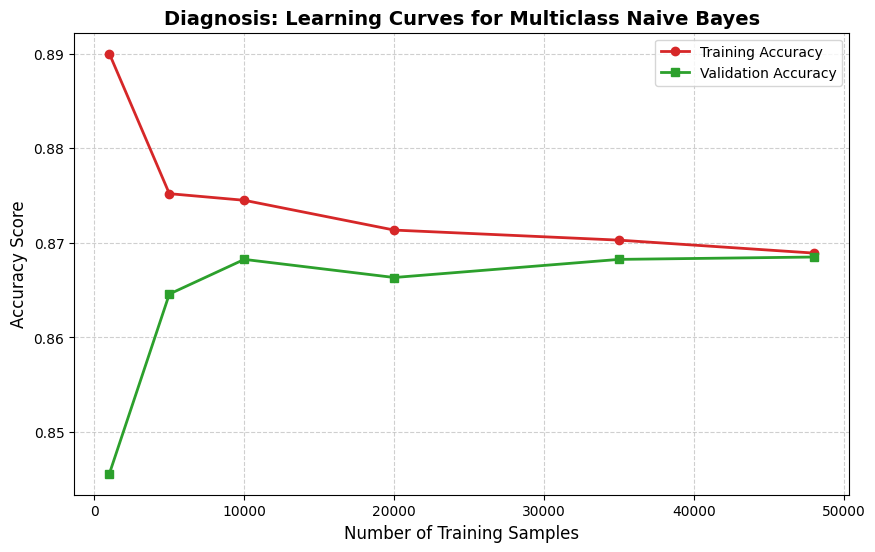


Success: Learning curve plot saved to results/phase2/nb_learning_curves.png


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare data (Usingbest configuration: PCA-50)
print("Loading data for Learning Curve Analysis...")
X_tr, X_val, _, y_tr, y_val, _ = preprocess(feature_method='pca', pca_components=50, binary=False)

# 2. Define training set sizes (from 1,000 samples up to full 48,000)
train_sizes = [1000, 5000, 10000, 20000, 35000, 48000]
train_scores = []
val_scores = []

print("Generating Learning Curves... (Processing multiple subsets)")

for size in train_sizes:
    # Initialize model with optimal hyperparameter (smoothing=0.1)
    model_lc = MulticlassNaiveBayes(smoothing=0.1)

    # Train on a smaller subset of the training data
    model_lc.fit(X_tr[:size], y_tr[:size])

    # Evaluate on the training subset
    train_pred = model_lc.predict(X_tr[:size])
    train_acc = np.mean(train_pred == y_tr[:size])
    train_scores.append(train_acc)

    # Evaluate on the full validation set
    val_pred = model_lc.predict(X_val)
    val_acc = np.mean(val_pred == y_val)
    val_scores.append(val_acc)

    print(f"  Training Size: {size:5d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

# 3. Create the Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores, 'o-', color="tab:red", label="Training Accuracy", linewidth=2)
plt.plot(train_sizes, val_scores, 's-', color="tab:green", label="Validation Accuracy", linewidth=2)

plt.title("Diagnosis: Learning Curves for Multiclass Naive Bayes", fontsize=14, fontweight='bold')
plt.xlabel("Number of Training Samples", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.6)

# 4. SAVE the third improvement plot
os.makedirs('results/phase2', exist_ok=True)
plt.savefig('results/phase2/nb_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSuccess: Learning curve plot saved to results/phase2/nb_learning_curves.png")